# 04 - Market Regimes Analysis
## What this notebook does
This notebook quantifies the relationship between electricity prices and the market regimes: time regime, negative price and forecast error. For each regime, we examine the trend line rather than relying on Pearson correlation alone, because the price formation is non-linear.
## Key questions
- What is the impact of 2022 energy crisis on electricity price?
- What are the drivers for negative electricity price?
- What are the patterns for negative electricity price?
- What are the forecast errors for each type of load generations?
- Does forecast errors have an impact on the electricity price?

## Data
Loaded from "data/processed/df_alls_cleaned.parquet" (produced by "01_data_processing.ipynb")

## Time Regime Analysis
Split the data set into 3 time periods: 2016-2020 (Pre-crisis baseline), 2021-2022 (Crisis onset and peak), 2023-2024 (Normalisation).

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import missingno as msno
import pyarrow
sys.path.append("../src")
import style 
style.apply_style()
pd.set_option("display.max_columns", 50)

df_alls = pd.read_parquet("../data/processed/df_alls_cleaned.parquet")
df_alls.head()

,MTU (CET/CEST),Area,Day-ahead Price (EUR/MWh),Actual Total Load (MW)_load,Day-ahead Total Load Forecast (MW)_load,Day-ahead (MW)_wind_offshore,Intraday (MW)_wind_offshore,Current (MW)_wind_offshore,Actual (MW)_wind_offshore,Day-ahead (MW)_wind_onshore,Intraday (MW)_wind_onshore,Current (MW)_wind_onshore,Actual (MW)_wind_onshore,Day-ahead (MW)_solar,Intraday (MW)_solar,Current (MW)_solar,Actual (MW)_solar
timestamp,,,,,,,,,,,,,,,,,
2016-01-01 00:00:00+01:00,01/01/2016 00:00:00 - 01/01/2016 01:00:00,BZN|FR,23.86,58639.0,58600.0,0.0,NaN,NaN,NaN,2313.42,NaN,NaN,2189.0,0.0,NaN,NaN,0.0
2016-01-01 01:00:00+01:00,01/01/2016 01:00:00 - 01/01/2016 02:00:00,BZN|FR,22.39,56733.0,56550.0,0.0,NaN,NaN,NaN,2003.04,NaN,NaN,1753.0,0.0,NaN,NaN,0.0
2016-01-01 02:00:00+01:00,01/01/2016 02:00:00 - 01/01/2016 03:00:00,BZN|FR,20.59,55127.0,56150.0,0.0,NaN,NaN,NaN,1743.72,NaN,NaN,1430.0,0.0,NaN,NaN,0.0
2016-01-01 03:00:00+01:00,01/01/2016 03:00:00 - 01/01/2016 04:00:00,BZN|FR,16.81,51744.0,52600.0,0.0,NaN,NaN,NaN,1490.09,NaN,NaN,1214.0,0.0,NaN,NaN,0.0
2016-01-01 04:00:00+01:00,01/01/2016 04:00:00 - 01/01/2016 05:00:00,BZN|FR,17.41,51744.0,49750.0,0.0,NaN,NaN,NaN,1238.09,NaN,NaN,1031.0,0.0,NaN,NaN,0.0


In [2]:
df_2016_2020 = df_alls[(df_alls.index.year >= 2016) & (df_alls.index.year <= 2020)].copy()
df_2021_2022 = df_alls[(df_alls.index.year >= 2021) & (df_alls.index.year <= 2022)].copy()
df_2023_2024 = df_alls[(df_alls.index.year >= 2023) & (df_alls.index.year <= 2024)].copy()

In [3]:
df_2016_2020["price_smooth"] = df_2016_2020["Day-ahead Price (EUR/MWh)"].rolling(window = 24).mean()
df_2021_2022["price_smooth"] = df_2021_2022["Day-ahead Price (EUR/MWh)"].rolling(window = 24).mean()
df_2023_2024["price_smooth"] = df_2023_2024["Day-ahead Price (EUR/MWh)"].rolling(window = 24).mean()

In [4]:
df_2016_2020["total_load_bins"] = pd.qcut(df_2016_2020["Day-ahead Total Load Forecast (MW)_load"], 20)
df_2021_2022["total_load_bins"] = pd.qcut(df_2021_2022["Day-ahead Total Load Forecast (MW)_load"], 20)
df_2023_2024["total_load_bins"] = pd.qcut(df_2023_2024["Day-ahead Total Load Forecast (MW)_load"], 20)

In [5]:
df_2016_2020["net_load"] = df_2016_2020["Day-ahead Total Load Forecast (MW)_load"] - (
    df_2016_2020["Day-ahead (MW)_solar"] + 
    df_2016_2020["Day-ahead (MW)_wind_offshore"] +
    df_2016_2020["Day-ahead (MW)_wind_onshore"]
)

df_2021_2022["net_load"] = df_2021_2022["Day-ahead Total Load Forecast (MW)_load"] - (
    df_2021_2022["Day-ahead (MW)_solar"] +
    df_2021_2022["Day-ahead (MW)_wind_offshore"] +
    df_2021_2022["Day-ahead (MW)_wind_onshore"]
)

df_2023_2024["net_load"] = df_2023_2024["Day-ahead Total Load Forecast (MW)_load"] - (
    df_2023_2024["Day-ahead (MW)_solar"]  +
    df_2023_2024["Day-ahead (MW)_wind_offshore"] +
    df_2023_2024["Day-ahead (MW)_wind_onshore"]
)

In [6]:
df_2016_2020["net_load_bins"] = pd.qcut(df_2016_2020["net_load"], 20)
df_2021_2022["net_load_bins"] = pd.qcut(df_2021_2022["net_load"], 20)
df_2023_2024["net_load_bins"] = pd.qcut(df_2023_2024["net_load"], 20)

In [7]:
df_2016_2020_load_price = df_2016_2020.groupby("total_load_bins", observed = True).agg(
    total_load_mean = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_2016_2020_load_price.head()

,total_load_mean,price_mean,price_std,price_90th,price_99th
total_load_bins,,,,,
"(29049.999, 36600.0]",34468.184675,23.078237,12.491590,39.359,51.7367
"(36600.0, 39050.0]",37920.703594,26.774873,12.458340,44.448,57.7918
"(39050.0, 40950.0]",40041.672026,29.112843,12.971111,46.128,64.9496
"(40950.0, 42650.0]",41817.321688,31.421388,13.181690,47.601,69.7508
"(42650.0, 44400.0]",43529.737642,32.883941,13.485360,49.602,70.6904


In [8]:
df_2016_2020_net_price = df_2016_2020.groupby("net_load_bins", observed = True).agg(
    net_load_mean = ("net_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_2016_2020_net_price

,net_load_mean,price_mean,price_std,price_90th,price_99th
net_load_bins,,,,,
"(19728.189, 32969.576]",30783.332079,19.247684,13.323787,34.176,50.1072
"(32969.576, 35311.816]",34212.355557,25.229580,12.004785,41.810,57.7499
"(35311.816, 37129.734]",36264.685271,28.141509,11.970276,44.418,60.8276
"(37129.734, 38785.902]",37942.994763,30.339662,12.074338,45.089,64.4889
"(38785.902, 40274.248]",39541.387546,32.292915,12.512297,47.838,66.8909
"(40274.248, 41751.71]",41016.503589,34.287250,12.586197,50.598,68.9904
"(41751.71, 43279.894]",42521.462359,35.962208,12.489402,51.107,72.0153
"(43279.894, 44650.264]",43976.439234,38.494275,13.103488,55.479,73.3478
"(44650.264, 45981.934]",45320.468554,39.740041,13.872062,57.354,75.8152


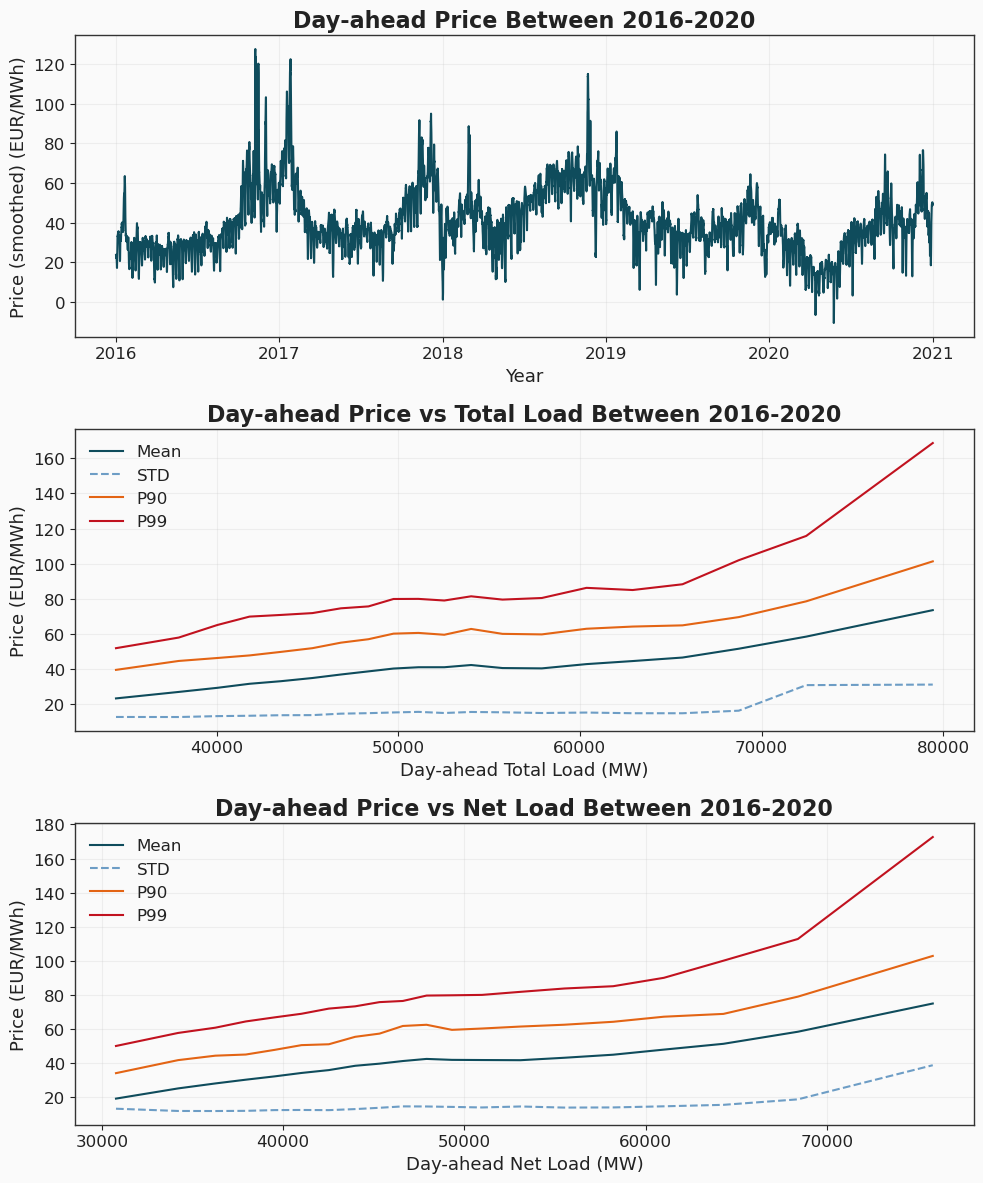

In [9]:
fig, axs = plt.subplots(figsize = (10, 12), nrows = 3)
sns.lineplot(data = df_2016_2020, x = df_2016_2020.index, y = "price_smooth", ax = axs[0], color = style.COLORS["primary"])
sns.lineplot(data = df_2016_2020_load_price, x = "total_load_mean", y = "price_mean", 
ax = axs[1], label = "Mean", color = style.COLORS["primary"])
sns.lineplot(data = df_2016_2020_load_price, x = "total_load_mean", y = "price_std", ax = axs[1], 
            color = style.COLORS["secondary"], ls = "--", label = "STD")
sns.lineplot(data = df_2016_2020_load_price, x = "total_load_mean", y = "price_90th", 
            ax = axs[1], label = "P90", color = style.COLORS["accent"])
sns.lineplot(data = df_2016_2020_load_price, x = "total_load_mean", y = "price_99th", 
            ax = axs[1], label = "P99", color = style.COLORS["crisis"])

sns.lineplot(data = df_2016_2020_net_price, x = "net_load_mean", y = "price_mean", 
            ax = axs[2], label = "Mean", color = style.COLORS["primary"])
sns.lineplot(data = df_2016_2020_net_price, x = "net_load_mean", y = "price_std", 
            ax = axs[2], color = style.COLORS["secondary"], ls = "--", label = "STD")
sns.lineplot(data = df_2016_2020_net_price, x = "net_load_mean", y = "price_90th", 
            ax = axs[2], label = "P90", color = style.COLORS["accent"])
sns.lineplot(data = df_2016_2020_net_price, x = "net_load_mean", y = "price_99th", 
            ax = axs[2], label = "P99", color = style.COLORS["crisis"])
axs[0].set_title("Day-ahead Price Between 2016-2020")
axs[0].set_xlabel("Year")
axs[0].set_ylabel("Price (smoothed) (EUR/MWh)")
axs[1].set_title("Day-ahead Price vs Total Load Between 2016-2020")
axs[1].set_xlabel("Day-ahead Total Load (MW)")
axs[1].set_ylabel("Price (EUR/MWh)")
axs[2].set_title("Day-ahead Price vs Net Load Between 2016-2020")
axs[2].set_xlabel("Day-ahead Net Load (MW)")
axs[2].set_ylabel("Price (EUR/MWh)")

plt.legend()
plt.tight_layout()
plt.show()

In [10]:
df_2021_2022_load_bins = df_2021_2022.groupby("total_load_bins", observed = True).agg(
    total_load_mean = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.quantile(x, 0.90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.quantile(x, 0.99))
)
df_2021_2022_load_bins.head()

,total_load_mean,price_mean,price_std,price_90th,price_99th
total_load_bins,,,,,
"(29649.999, 36050.0]",34009.920635,161.755964,131.388325,369.200,539.5458
"(36050.0, 38250.0]",37185.388128,176.010514,134.433072,379.110,571.0650
"(38250.0, 40100.0]",39260.388889,178.908733,142.993972,395.410,599.9624
"(40100.0, 41600.0]",40891.345029,179.799825,144.877735,401.480,667.9400
"(41600.0, 43350.0]",42528.443449,174.940246,141.667611,391.394,610.5992


In [11]:
df_2021_2022_net_price = df_2021_2022.groupby("net_load_bins", observed = True).agg(
    net_load_mean = ("net_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_2021_2022_net_price

,net_load_mean,price_mean,price_std,price_90th,price_99th
net_load_bins,,,,,
"(19407.249, 30637.616]",28299.408482,124.442603,117.208905,320.500,452.6575
"(30637.616, 32909.421]",31848.804258,156.066096,127.135263,348.650,564.9050
"(32909.421, 34580.04]",33775.466142,169.750856,133.189023,370.915,593.7475
"(34580.04, 36067.332]",35325.553265,175.038276,131.072192,375.050,564.2800
"(36067.332, 37423.118]",36764.529509,182.484543,140.333396,396.335,606.2800
"(37423.118, 38779.272]",38084.410103,198.971507,148.781777,429.560,653.3450
"(38779.272, 39967.741]",39363.616804,200.769155,150.881486,436.300,649.9925
"(39967.741, 41179.918]",40578.799030,207.508025,166.409223,468.610,729.0275
"(41179.918, 42227.704]",41696.347854,218.229635,161.684110,462.770,698.3050


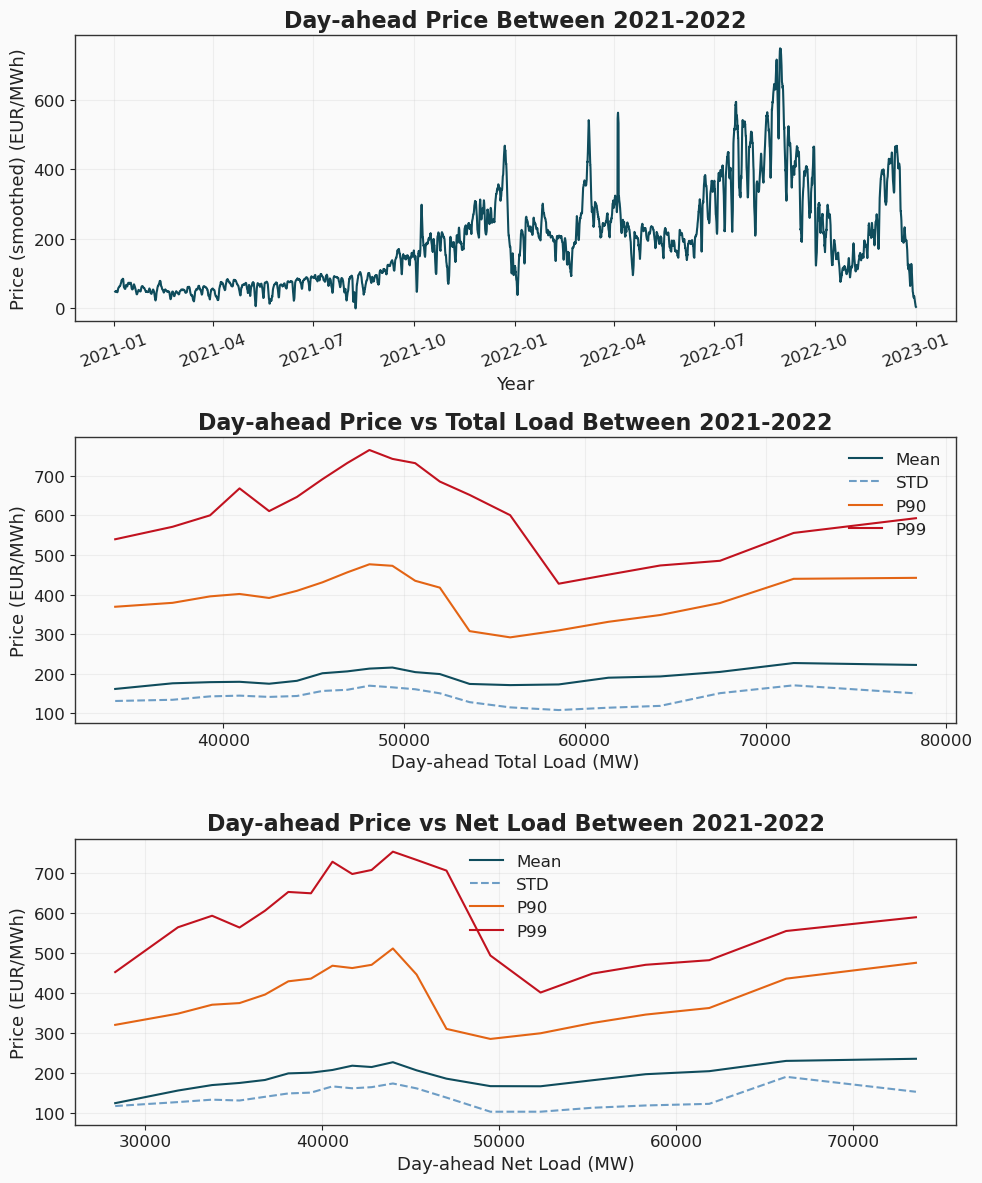

In [12]:
fig, axs = plt.subplots(figsize = (10, 12), nrows = 3)
sns.lineplot(data = df_2021_2022, x = df_2021_2022.index, y = "price_smooth", ax = axs[0], color = style.COLORS["primary"])
sns.lineplot(data = df_2021_2022_load_bins, x = "total_load_mean", y = "price_mean", 
ax = axs[1], label = "Mean", color = style.COLORS["primary"])
sns.lineplot(data = df_2021_2022_load_bins, x = "total_load_mean", y = "price_std", ax = axs[1], 
            color = style.COLORS["secondary"], ls = "--", label = "STD")
sns.lineplot(data = df_2021_2022_load_bins, x = "total_load_mean", y = "price_90th", 
            ax = axs[1], label = "P90", color = style.COLORS["accent"])
sns.lineplot(data = df_2021_2022_load_bins, x = "total_load_mean", y = "price_99th", 
            ax = axs[1], label = "P99", color = style.COLORS["crisis"])
sns.lineplot(data = df_2021_2022_net_price, x = "net_load_mean", y = "price_mean", 
            ax = axs[2], label = "Mean", color = style.COLORS["primary"])
sns.lineplot(data = df_2021_2022_net_price, x = "net_load_mean", y = "price_std", 
            ax = axs[2], color = style.COLORS["secondary"], ls = "--", label = "STD")
sns.lineplot(data = df_2021_2022_net_price, x = "net_load_mean", y = "price_90th", 
            ax = axs[2], label = "P90", color = style.COLORS["accent"])
sns.lineplot(data = df_2021_2022_net_price, x = "net_load_mean", y = "price_99th", 
            ax = axs[2], label = "P99", color = style.COLORS["crisis"])
axs[0].set_title("Day-ahead Price Between 2021-2022")
axs[0].set_xlabel("Year")
axs[0].tick_params("x", rotation = 20)
axs[0].set_ylabel("Price (smoothed) (EUR/MWh)")
axs[1].set_title("Day-ahead Price vs Total Load Between 2021-2022")
axs[1].set_xlabel("Day-ahead Total Load (MW)")
axs[1].set_ylabel("Price (EUR/MWh)")
axs[2].set_title("Day-ahead Price vs Net Load Between 2021-2022")
axs[2].set_xlabel("Day-ahead Net Load (MW)")
axs[2].set_ylabel("Price (EUR/MWh)")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
df_2023_2024_load_bins = df_2023_2024.groupby("total_load_bins", observed = True).agg(
    total_load_mean = ("Day-ahead Total Load Forecast (MW)_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_2023_2024_load_bins.head()

,total_load_mean,price_mean,price_std,price_90th,price_99th
total_load_bins,,,,,
"(27649.999, 34450.0]",32597.916667,49.064617,33.136427,91.493,105.5028
"(34450.0, 36550.0]",35565.188000,49.510069,36.145339,94.760,110.1778
"(36550.0, 38350.0]",37559.085407,52.776425,39.576542,100.000,118.0903
"(38350.0, 39900.0]",39156.746857,57.629646,41.489194,107.344,130.9014
"(39900.0, 41400.0]",40694.031465,59.960744,43.222656,111.522,135.6006


In [14]:
df_2023_2024_net_price = df_2023_2024.groupby("net_load_bins", observed = True).agg(
    net_load_mean = ("net_load", "mean"),
    price_mean = ("Day-ahead Price (EUR/MWh)", "mean"),
    price_std = ("Day-ahead Price (EUR/MWh)", "std"),
    price_90th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 90)),
    price_99th = ("Day-ahead Price (EUR/MWh)", lambda x: np.percentile(x, 99))
)
df_2023_2024_net_price

,net_load_mean,price_mean,price_std,price_90th,price_99th
net_load_bins,,,,,
"(12104.749, 26426.461]",23509.317278,12.785262,28.009833,57.634,85.1734
"(26426.461, 28799.341]",27735.030068,29.935599,32.555461,77.994,96.0436
"(28799.341, 30302.827]",29570.081859,42.914914,34.823251,87.284,106.1644
"(30302.827, 31779.05]",31076.542201,49.028438,34.651527,92.028,111.1440
"(31779.05, 33027.97]",32442.780399,51.596237,34.853656,95.182,115.2400
"(33027.97, 34184.868]",33622.622668,58.980274,33.824801,99.596,118.3820
"(34184.868, 35283.551]",34718.650456,63.726811,35.304659,105.000,129.5689
"(35283.551, 36383.234]",35844.173090,65.727035,35.531470,107.894,132.0000
"(36383.234, 37450.433]",36921.793341,71.352075,35.427412,110.912,135.5384


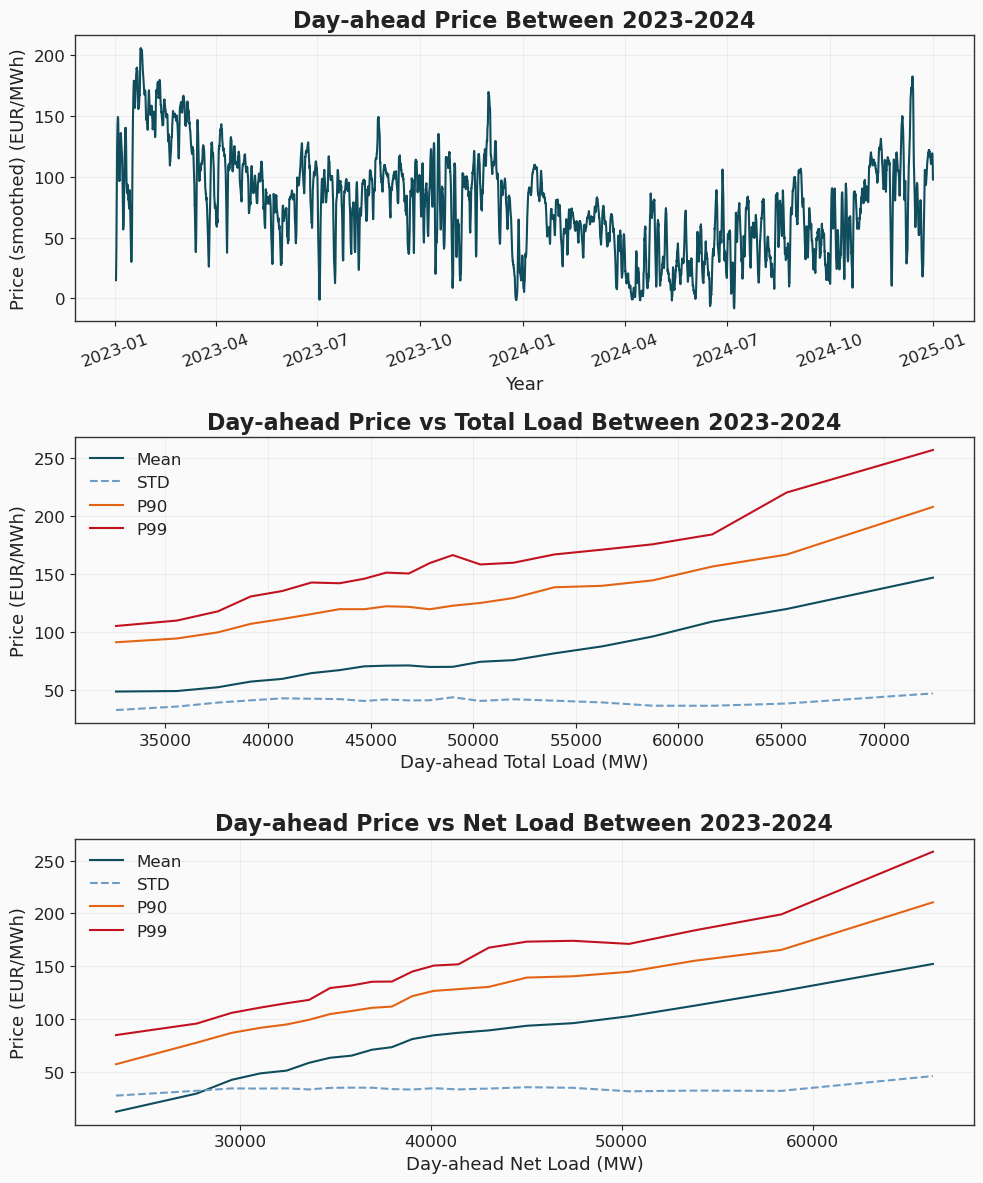

In [15]:
fig, axs = plt.subplots(figsize = (10, 12), nrows = 3)
sns.lineplot(data = df_2023_2024, x = df_2023_2024.index, y = "price_smooth", ax = axs[0], color = style.COLORS["primary"])
sns.lineplot(data = df_2023_2024_load_bins, x = "total_load_mean", y = "price_mean", 
            ax = axs[1], label = "Mean", color = style.COLORS["primary"])
sns.lineplot(data = df_2023_2024_load_bins, x = "total_load_mean", y = "price_std", ax = axs[1], 
            color = style.COLORS["secondary"], ls = "--", label = "STD")
sns.lineplot(data = df_2023_2024_load_bins, x = "total_load_mean", y = "price_90th", 
            ax = axs[1], label = "P90", color = style.COLORS["accent"])
sns.lineplot(data = df_2023_2024_load_bins, x = "total_load_mean", y = "price_99th", 
            ax = axs[1], label = "P99", color = style.COLORS["crisis"])
sns.lineplot(data = df_2023_2024_net_price, x = "net_load_mean", y = "price_mean", 
            ax = axs[2], label = "Mean", color = style.COLORS["primary"])
sns.lineplot(data = df_2023_2024_net_price, x = "net_load_mean", y = "price_std", 
            ax = axs[2], color = style.COLORS["secondary"], ls = "--", label = "STD")
sns.lineplot(data = df_2023_2024_net_price, x = "net_load_mean", y = "price_90th", 
            ax = axs[2], label = "P90", color = style.COLORS["accent"])
sns.lineplot(data = df_2023_2024_net_price, x = "net_load_mean", y = "price_99th", 
            ax = axs[2], label = "P99", color = style.COLORS["crisis"])
axs[0].set_title("Day-ahead Price Between 2023-2024")
axs[0].set_xlabel("Year")
axs[0].tick_params("x", rotation = 20)
axs[0].set_ylabel("Price (smoothed) (EUR/MWh)")
axs[1].set_title("Day-ahead Price vs Total Load Between 2023-2024")
axs[1].set_xlabel("Day-ahead Total Load (MW)")
axs[1].set_ylabel("Price (EUR/MWh)")
axs[2].set_title("Day-ahead Price vs Net Load Between 2023-2024")
axs[2].set_xlabel("Day-ahead Net Load (MW)")
axs[2].set_ylabel("Price (EUR/MWh)")
plt.legend()
plt.tight_layout()
plt.show()

Both total load and net load are good indicators for day-ahead price in the time regime in normal markets. However, they become uninformative during structural shocks, e.g. 2022 energy crisis. For the modelling section, we need to construct a model with a feature specifying if the regime __is_crisis__ in order to better predict price in structural shock period.

## Negative Prices

In [16]:
negative_price = df_alls[df_alls["Day-ahead Price (EUR/MWh)"] < 0].copy()
negative_price["Day-ahead Price (EUR/MWh)"].count()

np.int64(713)

#### Negative Price VS Hours of the Day

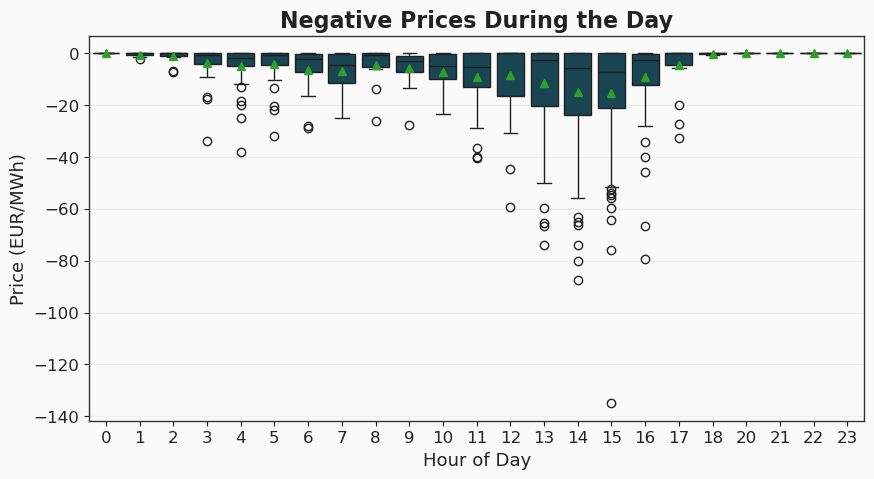

In [17]:
plt.figure()
sns.boxplot(data = negative_price, x = negative_price.index.hour, y = "Day-ahead Price (EUR/MWh)", showmeans = True, color = style.COLORS["primary"])
plt.xlabel("Hour of Day")
plt.ylabel("Price (EUR/MWh)")
plt.title("Negative Prices During the Day")
plt.show()

Negative price happens between 4:00-17:00 of the day. The negative price inter quantile range (IQR) stretches out significantly between 12:00-16:00.  

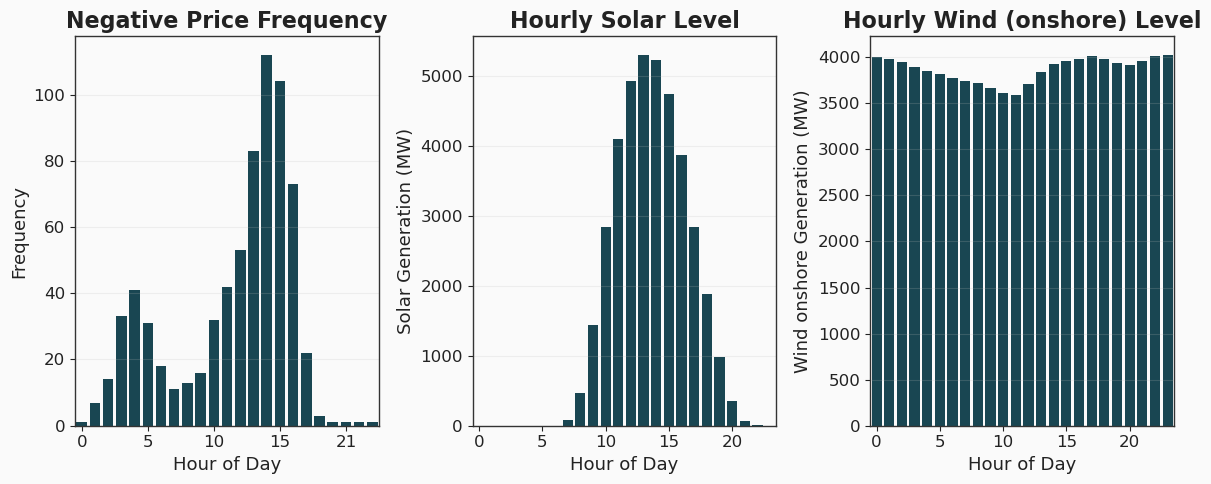

In [18]:
neg_price_hour = negative_price.index.hour.value_counts().sort_index().reset_index()
df_solar_pred_hour = df_alls.groupby(df_alls.index.hour)["Day-ahead (MW)_solar"].mean().reset_index()
df_wind_onshore_hour = df_alls.groupby(df_alls.index.hour)["Day-ahead (MW)_wind_onshore"].mean().reset_index()

fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12,5))
sns.barplot(data = neg_price_hour, x = "timestamp", y = "count", ax = axes[0], color = style.COLORS["primary"])
axes[0].set_title("Negative Price Frequency")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(range(0, 24, 5))

sns.barplot(data = df_solar_pred_hour, x = "timestamp", y = "Day-ahead (MW)_solar", ax = axes[1], color = style.COLORS["primary"])
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Solar Generation (MW)")
axes[1].set_title("Hourly Solar Level")
axes[1].set_xticks(range(0, 24, 5))

sns.barplot(data = df_wind_onshore_hour, x = "timestamp", y = "Day-ahead (MW)_wind_onshore", ax = axes[2], color = style.COLORS["primary"])
axes[2].set_title("Hourly Wind (onshore) Level")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Wind onshore Generation (MW)")
axes[2].set_xticks(range(0, 24, 5))

plt.tight_layout()
plt.show()

- Solar shows interday cycle while wind shows rather consistent generations over the day. Solar generation shows effect on the negative price counts. Wind doesn't cause negative prices the way solar does. 
- At night, energy production sources are wind, gas etc., which are partially dispatchable. Therefore, the grid can absorb nighttime wind without prices going negative.
- During the day, solar coexist with nuclear, which cannot be easily reduced or terminated. Therefore, the collision creates negative prices. 

#### Negative Price VS Day of the Week

In [19]:
weekday_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

neg_price_week = negative_price.index.dayofweek.value_counts().sort_index()
neg_price_week.index = neg_price_week.index.map(weekday_map)

df_solar_pred_week = df_alls.groupby(df_alls.index.dayofweek)["Day-ahead (MW)_solar"].mean().sort_index()
df_solar_pred_week.index = df_solar_pred_week.index.map(weekday_map)
df_solar_pred_week = df_solar_pred_week.reset_index()

df_wind_onshore_week = df_alls.groupby(df_alls.index.dayofweek)["Day-ahead (MW)_wind_onshore"].mean().sort_index()
df_wind_onshore_week.index = df_wind_onshore_week.index.map(weekday_map)
df_wind_onshore_week = df_wind_onshore_week.reset_index()

In [20]:
neg_price_week

timestamp
Monday        78
Tuesday       50
Wednesday     24
Thursday      25
Friday        38
Saturday     122
Sunday       376
Name: count, dtype: int64

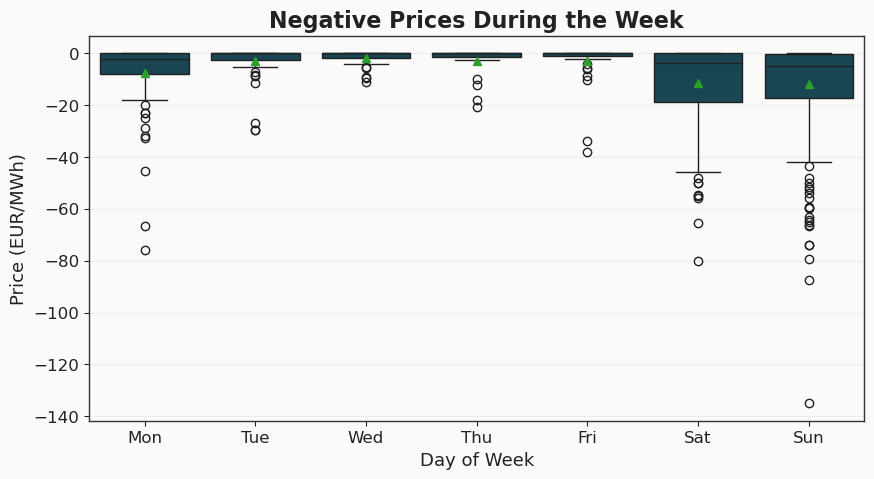

In [21]:
plt.figure(figsize = (10, 5))
sns.boxplot(data = negative_price, x = negative_price.index.dayofweek, y = "Day-ahead Price (EUR/MWh)", showmeans = True, color = style.COLORS["primary"])
plt.xlabel("Day of Week")
plt.ylabel("Price (EUR/MWh)")
plt.title("Negative Prices During the Week")
plt.xticks(range(0, 7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.show()

Saturday and Sunday have similar IQR of the negative price, whereas Tue-Fri the IQR is very small. 

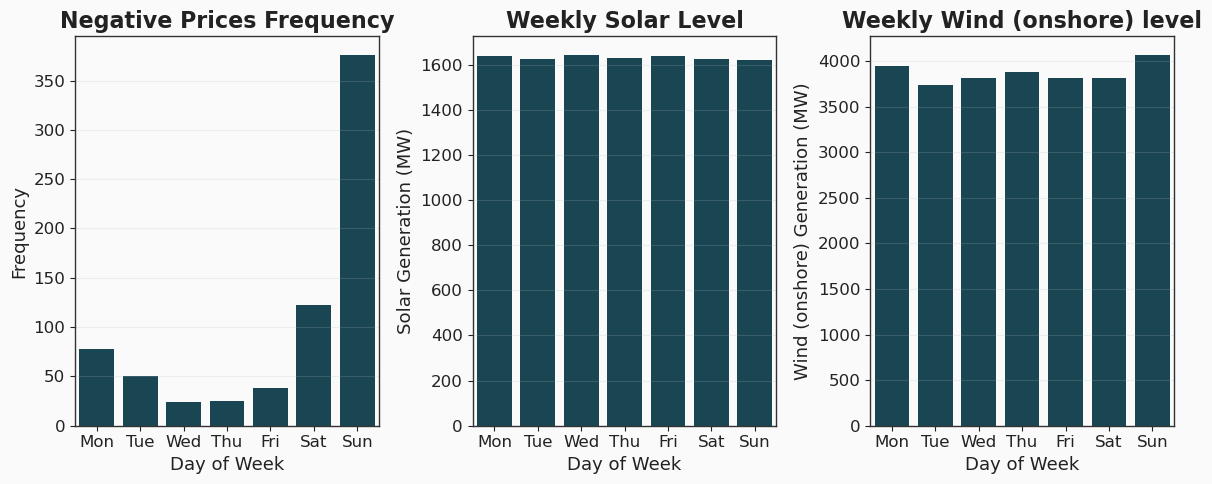

In [22]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (12,5))
sns.barplot(data = neg_price_week.reset_index(), x = "timestamp", y = "count", ax = axes[0], color = style.COLORS["primary"])
axes[0].set_title("Negative Prices Frequency")
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(range(0, 7))
axes[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

sns.barplot(data = df_solar_pred_week, x = "timestamp", y = "Day-ahead (MW)_solar", ax = axes[1], color = style.COLORS["primary"])
axes[1].set_xticks(range(0, 7))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Solar Generation (MW)")
axes[1].set_title("Weekly Solar Level")

sns.barplot(data = df_wind_onshore_week, x = "timestamp", y = "Day-ahead (MW)_wind_onshore", ax = axes[2], color = style.COLORS["primary"])
axes[2].set_xticks(range(0, 7))
axes[2].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[2].set_xlabel("Day of Week")
axes[2].set_ylabel("Wind (onshore) Generation (MW)")
axes[2].set_title("Weekly Wind (onshore) level")
plt.tight_layout()
plt.show()

Weekend has more negative price occurance, with Sunday owns triple negative price counts than Saturday. Solar and wind generations show consistent amount through the week. The low demand on Sunday, and the non-dispatchable generations likely contribute to the surge of negative price on Sundays.

#### Negative Price VS Month

In [23]:
neg_price_month = negative_price.index.month.value_counts().sort_index().reset_index()

df_solar_pred_month = df_alls.groupby(df_alls.index.month)["Day-ahead (MW)_solar"].mean().sort_index()
df_solar_pred_month = df_solar_pred_month.reset_index()

df_wind_onshore_month = df_alls.groupby(df_alls.index.month)["Day-ahead (MW)_wind_onshore"].mean().sort_index()
df_wind_onshore_month = df_wind_onshore_month.reset_index()

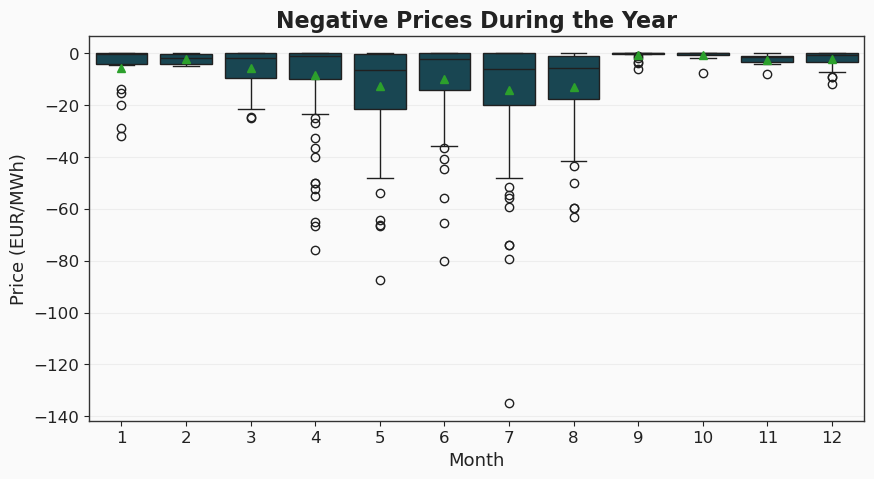

In [24]:
plt.figure(figsize = (10, 5))
sns.boxplot(data = negative_price, x = negative_price.index.month, y = "Day-ahead Price (EUR/MWh)", showmeans = True, color = style.COLORS["primary"])
plt.xlabel("Month")
plt.ylabel("Price (EUR/MWh)")
plt.title("Negative Prices During the Year")
plt.show()

The negative price IQR is higher in summer months. In September and October the IQR are almost zero. 

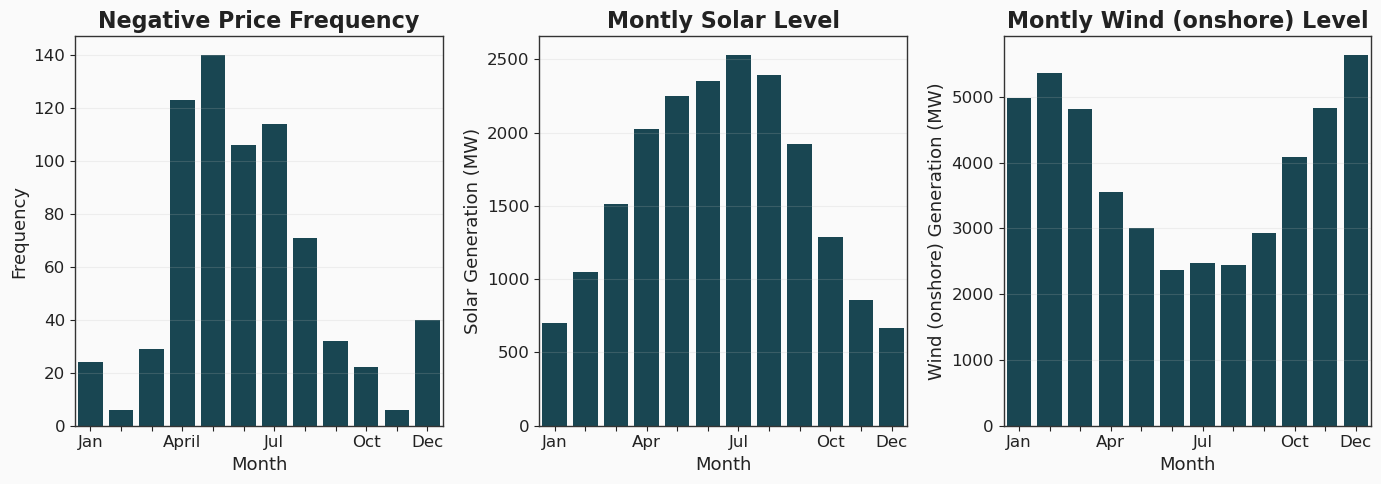

In [25]:
fig, axes = plt.subplots(ncols = 3, nrows = 1, figsize = (14, 5))
sns.barplot(data = neg_price_month, x = "timestamp", y = "count", ax = axes[0], color = style.COLORS["primary"])
axes[0].set_title("Negative Price Frequency")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Frequency")
axes[0].set_xticks(range(0, 12), ["Jan", " ", " ", "April", " ", " ", "Jul", " ", " ", "Oct", " ", "Dec"])

sns.barplot(data = df_solar_pred_month, x = "timestamp", y = "Day-ahead (MW)_solar", ax = axes[1], color = style.COLORS["primary"])
axes[1].set_title("Montly Solar Level")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Solar Generation (MW)")
axes[1].set_xticks(range(0, 12), ["Jan", " ", " ", "Apr", " ", " ", "Jul", " ", " ", "Oct", " ", "Dec"])

sns.barplot(data = df_wind_onshore_month, x = "timestamp", y = "Day-ahead (MW)_wind_onshore", ax = axes[2], color = style.COLORS["primary"])
axes[2].set_title("Montly Wind (onshore) Level")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Wind (onshore) Generation (MW)")
axes[2].set_xticks(range(0, 12), ["Jan", " ", " ", "Apr", " ", " ", "Jul", " ", " ", "Oct", " ", "Dec"])

plt.tight_layout()
plt.show()

The count of negative price peaks from April until July. In Feburary and November the counts are the lowest. Solar generation shows a clear annual cycle in the shape of a bell, with summer months provide more negative price and winter months less. Wind generations show an opposite distribution through the months, with summer months show less wind generations and winter months more. Solar generation contributes to the count of negative prices more visible than wind generations.

#### Negative Price VS Year

In [26]:
neg_price_year = negative_price.index.year.value_counts().sort_index().reset_index()
df_solar_pred_year = df_alls.groupby(df_alls.index.year)["Day-ahead (MW)_solar"].mean().sort_index().reset_index()
df_wind_onshore_year = df_alls.groupby(df_alls.index.year)["Day-ahead (MW)_wind_onshore"].mean().sort_index().reset_index()

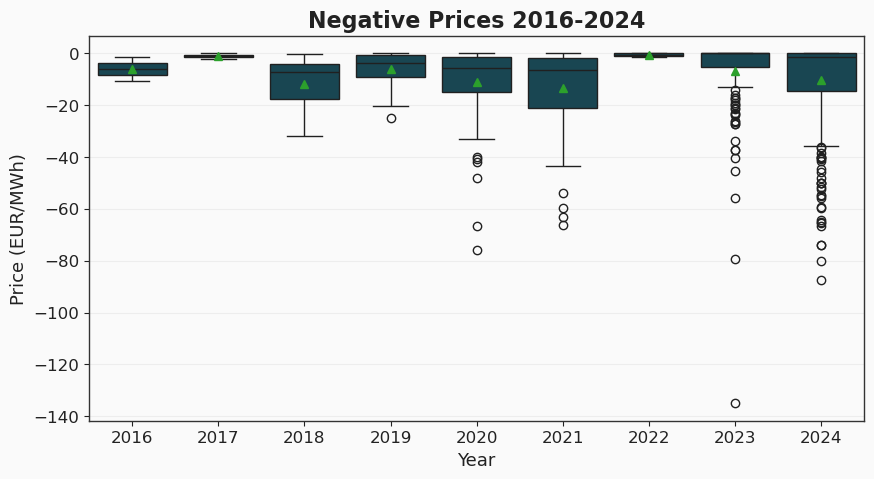

In [27]:
plt.figure(figsize = (10, 5))
sns.boxplot(data = negative_price, x = negative_price.index.year, y = "Day-ahead Price (EUR/MWh)", showmeans = True, color = style.COLORS["primary"])
plt.xlabel("Year")
plt.ylabel("Price (EUR/MWh)")
plt.title("Negative Prices 2016-2024")
plt.show()

The negative price IQR extends the most in 2021, followed by 2024, 2018, 2020. 2017 and 2022 the negative price IQR are almost zero.

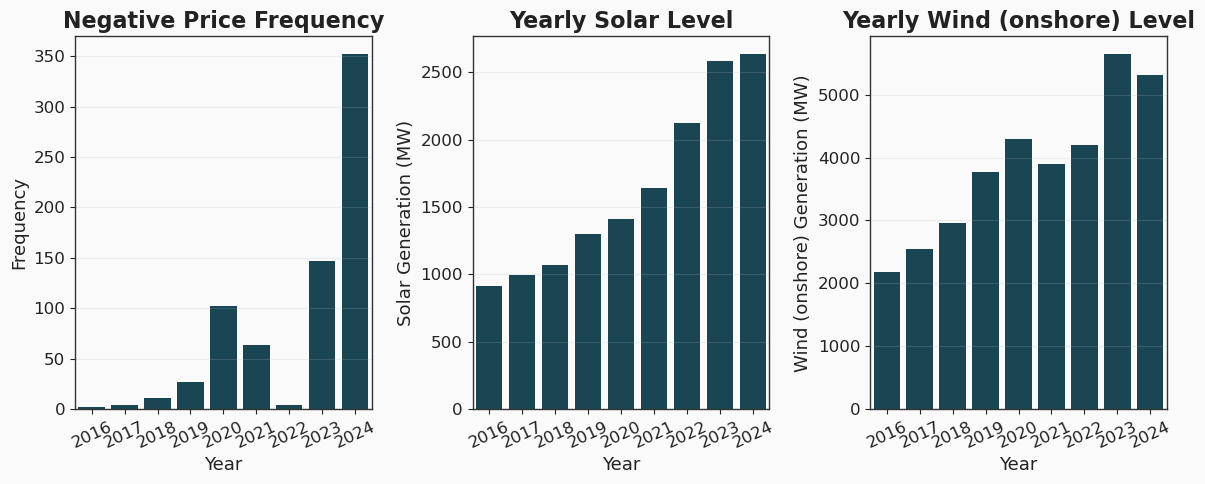

In [28]:
fig, axes = plt.subplots(ncols = 3, nrows = 1, figsize = (12, 5))
sns.barplot(data = neg_price_year, x = "timestamp", y = "count", ax = axes[0], color = style.COLORS["primary"])
axes[0].set_title("Negative Price Frequency")
axes[0].set_xlabel("Year")
axes[0].tick_params("x", rotation = 25)
axes[0].set_ylabel("Frequency")
sns.barplot(data = df_solar_pred_year, x = "timestamp", y = "Day-ahead (MW)_solar", ax = axes[1], color = style.COLORS["primary"])
axes[1].set_title("Yearly Solar Level")
axes[1].set_xlabel("Year")
axes[1].tick_params("x", rotation = 25)
axes[1].set_ylabel("Solar Generation (MW)")
sns.barplot(data = df_wind_onshore_year, x = "timestamp", y = "Day-ahead (MW)_wind_onshore", ax = axes[2], color = style.COLORS["primary"])
axes[2].set_title("Yearly Wind (onshore) Level")
axes[2].set_ylabel("Wind (onshore) Generation (MW)")
axes[2].set_xlabel("Year")
axes[2].tick_params("x", rotation = 25)
plt.tight_layout()
plt.show()

The negative price counts are the lowest in 2016, followed by 2017 and 2022. The most negative price occurrance is in 2024. The solar generation shows steady growth between 2016-2024. The wind generations show some fluctuations although the overall trend is climbing as well. The growing renewable generations likely contributed to the growth of negative price incidents. 

#### Negative Price Monthly x Yearly

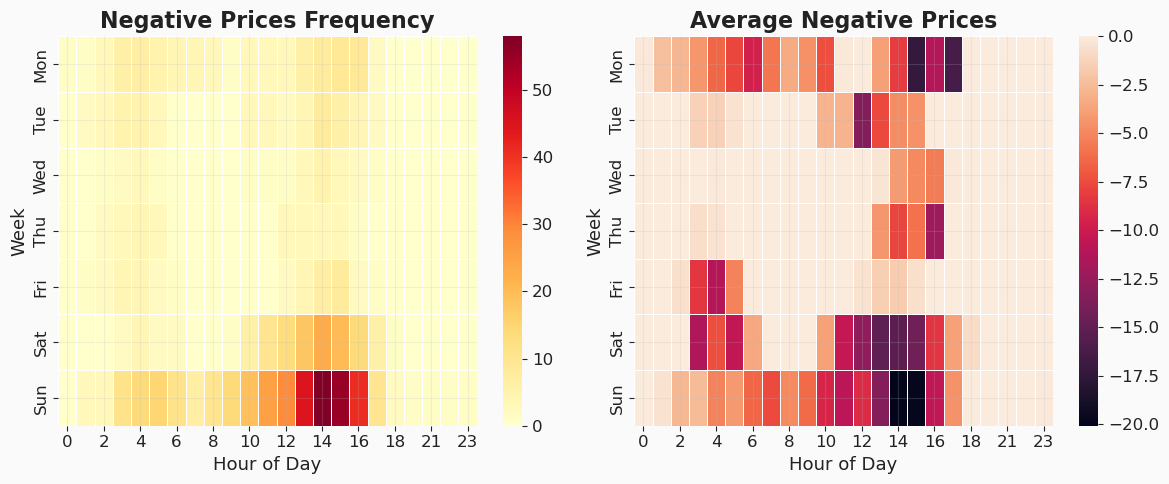

In [44]:
negative_price_hour_week_count = (
    negative_price.groupby(
        [negative_price.index.dayofweek, negative_price.index.hour])
        ["Day-ahead Price (EUR/MWh)"].count().unstack(level = 1).fillna(0))

negative_price_hour_week_mean = (
    negative_price.groupby([negative_price.index.dayofweek, negative_price.index.hour])
    ["Day-ahead Price (EUR/MWh)"].mean().unstack(level = 1).fillna(0)
)

fig, axes = plt.subplots(ncols = 2, figsize = (12, 5))
sns.heatmap(negative_price_hour_week_count, cmap = "YlOrRd", linewidth = 0.5, annot = False, ax = axes[0])
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Week")
axes[0].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[0].set_title("Negative Prices Frequency")

sns.heatmap(negative_price_hour_week_mean, cmap = "rocket", linewidth = 0.5, annot = False, ax = axes[1])
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Week")
axes[1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_title("Average Negative Prices")

plt.tight_layout()
plt.show()

The heatmaps systematically show the distributions of negative prices frequency and average negative prices happened during the week in each hour. 

Negative prices occur mainly on weekwends, Sundays in particular. Between 12-16h is the highest frequency of the negative prices. 

Average negative prices rocket in the afternoons except on Fridays. The mornings where average negative prices stand out are Mondays, Fridays and weekends, notably between 3-6h. 

These observations confirm the negative price is caused by low demand in company with high renewable generations.

Next we examine the negative prices occurrences and averages in the scale of months in the year. 

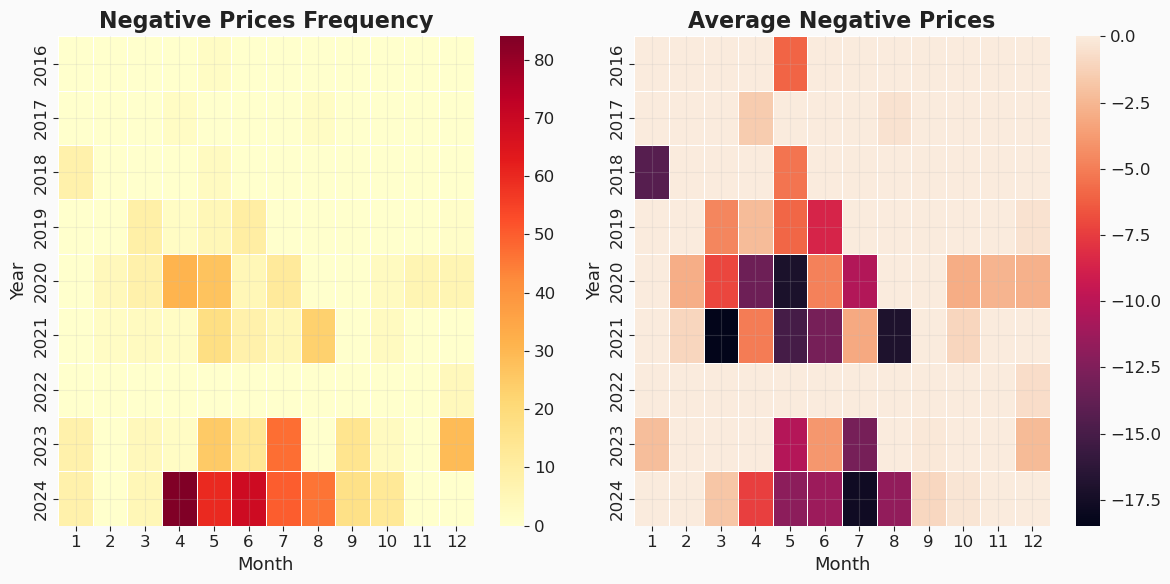

In [43]:
negative_price_year_month_count = (negative_price.groupby([negative_price.index.year, negative_price.index.month])
                             ["Day-ahead Price (EUR/MWh)"].count().unstack(level = 1).fillna(0))
negative_price_year_month_mean = (negative_price.groupby([negative_price.index.year, negative_price.index.month])
                             ["Day-ahead Price (EUR/MWh)"].mean().unstack(level = 1).fillna(0))

fig, axes = plt.subplots(ncols = 2, figsize = (12, 6))
sns.heatmap(negative_price_year_month_count, cmap = "YlOrRd", linewidth = 0.5, annot = False, ax = axes[0])
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Year")
axes[0].set_title("Negative Prices Frequency")
sns.heatmap(negative_price_year_month_mean, cmap = "rocket", linewidth = 0.5, annot = False, ax = axes[1])
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Year")
axes[1].set_title("Average Negative Prices")

plt.tight_layout()
plt.show()

The occurrance of negative price happens much more often in 2024 spring and summer months. In other years, it happens more often also from April to August. Except 2022, where the energy shock changed the market structure.

The mean negative price indicates how low the negative price can be. Lowest mean negative happens in 2020, 2021 and 2024, from spring to August. 

The trend of more negative price and lower negative mean price is visible when 2022 is excluded.

**Negative price** in France is caused by the interaction between renewable expansion, inflexible baseload generations, low electricity demand, and limited storage flexibility. In particular, solar generation appears to be the strongest recurring driver, while wind contributes more irregularly through weather-dependent variability.

# Summary of Market Regime Analysis
- Both total load and net load are good predictors for day-ahead price in normal markets. However, they become uninformative during structural shocks, e.g. 2022 energy crisis.
- Negative price presence shows patterns in response to temporal regime: daily pattern, most negative price occurs during the afternoon; weekly patter, negative price occurs significantly more frequent on Sundays; monthly pattern, negative price occurs much more frequent in April to July; yearly pattern, negative price occurs the most in 2024 and nearly zero in 2016-2017 and 2022. 
- Solar generations can partially explain the pattern of negative price counts in the hourly and montly patterns, while wind generations are slightly less relevant. 
- In the whole dataset, wind onshore and solar generations are both slightly overforecasted with a much larger STD, while wind offshore generation is slightly underforecasted. However, in the negative price dataset, both wind onshore and solar generations are sustantially overforecasted, indicating the negative price is not a result of overprediction. 

## Implications for modelling
The modelling section will include a crisis_year indicator, is_weekeknd and is_negative_price_risk_hour and is_negative_price_risk_month as cyclical features.